#  The simple linear regression model (SLR)

### Econometrics A (ØkA)

Wooldridge (Ch. 2)

Bertel Schjerning

Department of Economics, University of Copenhagen


# Part 1: Timeløn og uddannelse (OLS estimation)

### Eksempel 1: Timeløn og uddannelse
Estimation af simpel model for timeløn og uddannelse:
$$
		\text{timeløn}_i = \beta _{0}+\beta _{1}\text{uddannelse}_i+u_i
$$
- Vi benytter data fra Danmarks Statistik.
    - Data indeholder $N=1.078$ tilfældigt udvalgte personer i 1994.	
	- For hvert individ, $i$, har vi information om timelønnen, køn, antal årsuddannelse, single, alder og erhvervserfaring.
- Datasættet er afgrænset således:
    - 20-68 årige.			
	- Lønmodtagere.			
	- Timeløn på mere end 40 kr.

### Indlæs data og relevante biblioteker

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the data
data = pd.read_stata(r"../data/wage.dta") 
data['const'] = 1

# Descriptive statistics
descriptive_stats = data.describe()

# Display the descriptive statistics
display(descriptive_stats)

,sex,age,wage,educ,experience,single,const
count,1078.000000,1078.000000,1078.000000,1078.000000,1078.000000,1078.000000,1078.0
mean,1.479592,39.302412,139.192950,11.449907,14.626375,0.258813,1.0
std,0.499815,11.068010,47.357094,3.311553,8.564899,0.438186,0.0
min,1.000000,20.000000,44.000000,0.000000,0.139000,0.000000,1.0
25%,1.000000,30.000000,110.000000,10.000000,7.833750,0.000000,1.0
50%,1.000000,39.000000,129.000000,12.000000,13.823500,0.000000,1.0
75%,2.000000,48.000000,159.000000,13.000000,20.913500,1.000000,1.0
max,2.000000,68.000000,300.000000,18.000000,31.000000,1.000000,1.0


### OLS-estimatoren for den simple lineære regressionsmodel

Model:
$$
y=\beta _{0}+\beta_{1}x+u
$$

OLS-estimator (hældning):
$$
\hat{\beta}_{1} = \frac{\sum_{i=1}^{n}(x_{i}-\bar{x})(y_{i}-\bar{y})}{\sum_{i=1}^{n}(x_{i}-\bar{x})^{2}} = \frac{\widehat{\operatorname{cov}}(x_i,y_i)}{\widehat{\operatorname{var}}(x_i)}
$$

OLS-estimator (konstantled):
$$
\hat{\beta}_{0} = \bar{y} - \hat{\beta}_{1} \bar{x}
$$

### Simpel OLS - direkte beregning vha NumPy

In [2]:
# Forbered data til OLS - konverter fra dataframe til numpy array
y = data['wage'].values   
X = data['educ'].values

# Beregn variansen af X (educ)
var_X = np.sum((X - np.mean(X)) ** 2) / len(X)

# og kovariansen mellem X (educ) og y (wage)
cov_XY = np.sum((X - np.mean(X)) * (y - np.mean(y))) / len(X)

# OLS estimater af beta0 (intercept) og beta1 (hældning)
bhat1 = cov_XY / var_X
bhat0 = np.mean(y) - bhat1 * np.mean(X)

# Udskriv resultater
print(f"cov_XY:        {cov_XY:8.4f}")
print(f"var_X:         {var_X:8.4f}\n")
print(f"bhat0 (const): {bhat0:8.4f}")
print(f"bhat1 (educ):  {bhat1:8.4f}")

cov_XY:         46.7499
var_X:          10.9562

bhat0 (const):  90.3364
bhat1 (educ):    4.2670


### OLS regression ved brug af OLS fra statsmodels

In [3]:
#!pip install statsmodels # uncomment to install
import statsmodels.api as sm

# OLS estimation vha OLS fra statsmodels
model_sm = sm.OLS(data['wage'], data[['const', 'educ']]).fit()
print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                   wage   R-squared:                       0.089
Model:                            OLS   Adj. R-squared:                  0.088
Method:                 Least Squares   F-statistic:                     105.2
Date:                Tue, 01 Sep 2026   Prob (F-statistic):           1.32e-23
Time:                        11:40:07   Log-Likelihood:                -5637.5
No. Observations:                1078   AIC:                         1.128e+04
Df Residuals:                    1076   BIC:                         1.129e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         90.3364      4.959     18.215      0.0

# Part 2: Timeløn og uddannelse (Goodness of fit)

### Goodness of fit, $R^2$

Total sum of squares:
$$SST \equiv \sum_{i=1}^{n}(y_i-\bar{y})^2$$

Regression sum of squares:
$$SSR \equiv \sum_{i=1}^{n}(\hat{y}_i-\bar{y})^2$$

Sum of squared errors:
$$SSE \equiv \sum_{i=1}^{n}\hat{u}_i^2$$

Goodness of fit:
$$R^2 \equiv \frac{SSR}{SST} = 1 - \frac{SSE}{SST}$$

### SST, SSE, SSR og $R^2$ - direkte beregning vha NumPy

In [4]:
# Forudsagte værdier
yhat = bhat0 + bhat1 * X

# Goodness of fit (Wooldridge notation)
SST = np.sum((y - np.mean(y)) ** 2)     # Total sum of squares
SSR = np.sum((yhat - np.mean(y)) ** 2)  # Regression sum of squares
SSE = np.sum((y - yhat) ** 2)           # Sum of squared errors
R2 = SSR / SST

print(f"SST (Total sum of squares):      {SST:15.2f}")
print(f"SSR (Regression sum of squares): {SSR:15.2f}")
print(f"SSE (Sum of squared errors):      {SSE:15.2f}")
print(f"R^2 (Goodness of fit):            {R2:15.4f}")

SST (Total sum of squares):           2415381.87
SSR (Regression sum of squares):       215040.48
SSE (Sum of squared errors):           2200341.38
R^2 (Goodness of fit):                     0.0890


### Sammenligning med statsmodels

In [5]:
# Translate statsmodels names into Wooldridge notation.
SST_sm = model_sm.centered_tss
SSR_sm = model_sm.ess  # statsmodels: explained sum of squares
SSE_sm = model_sm.ssr  # statsmodels: sum of squared residuals
R2_sm = model_sm.rsquared

print(f"SST (Total sum of squares):      {SST_sm:15.2f}")
print(f"SSR (Regression sum of squares): {SSR_sm:15.2f}")
print(f"SSE (Sum of squared errors):      {SSE_sm:15.2f}")
print(f"R^2 (Goodness of fit):            {R2_sm:15.4f}")

SST (Total sum of squares):           2415381.87
SSR (Regression sum of squares):       215040.48
SSE (Sum of squared errors):           2200341.38
R^2 (Goodness of fit):                     0.0890


### Summary output for statsmodels
- $R^2$ og meget andet findes i summary output 
- Men ikke SST, SSR, SSE og mange andre ting
- Med NumPy kan alt lade sig gøre, hvis du kender formlen i Wooldridge

In [6]:
print(model_sm.summary()) # uncomment to see output from statsmodels

                            OLS Regression Results                            
Dep. Variable:                   wage   R-squared:                       0.089
Model:                            OLS   Adj. R-squared:                  0.088
Method:                 Least Squares   F-statistic:                     105.2
Date:                Tue, 01 Sep 2026   Prob (F-statistic):           1.32e-23
Time:                        11:40:07   Log-Likelihood:                -5637.5
No. Observations:                1078   AIC:                         1.128e+04
Df Residuals:                    1076   BIC:                         1.129e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         90.3364      4.959     18.215      0.0

# Part 3: Timeløn og uddannelse (Varians og standard fejl)

### Residualvarians, variansen af OLS-estimatoren og standardfejl

Givet modellen
$$
y_i = \beta_0 + \beta_1 x_i + u_i,
$$
estimeres residualvariansen som
$$
\hat{\sigma}^2 = \frac{1}{n-2} \sum_{i=1}^{n} \hat{u}_i^2.
$$

De estimerede varianser er
$$
\widehat{\operatorname{Var}}(\hat{\beta}_1 \mid X)
= \frac{\hat{\sigma}^2}{\sum_{i=1}^{n} (x_i - \bar{x})^2},
$$
$$
\widehat{\operatorname{Var}}(\hat{\beta}_0 \mid X)
= \frac{\hat{\sigma}^2 \cdot \frac{1}{n}\sum_{i=1}^{n}x_i^2}
{\sum_{i=1}^{n}(x_i - \bar{x})^2}.
$$

Standardfejlene er kvadratrødderne af de estimerede varianser.

### Implementer disse i NumPy

In [7]:
n = len(y)
X_mean = np.mean(X)
X_squared_sum = np.sum(X**2)

# Residualvarians
residuals = y - (bhat0 + bhat1 * X)
sigma_squared_hat = np.sum(residuals**2) / (n - 2)

# Estimerede varianser og standardfejl
SST_x = np.sum((X - X_mean)**2)
se_beta1 = np.sqrt(sigma_squared_hat / SST_x)
se_beta0 = np.sqrt(sigma_squared_hat * (X_squared_sum / n) / SST_x)

print(f"{'Parameter':<20} {'Estimate':>10} {'Std. Error':>15} {'Variance':>15}")
print("-" * 70)
print(f"{'bhat0 (const)':<20} {bhat0:>10.4f} {se_beta0:>15.4f} {se_beta0**2:>15.4f}")
print(f"{'bhat1 (educ)':<20} {bhat1:>10.4f} {se_beta1:>15.4f} {se_beta1**2:>15.4f}")
print(f"{'Residual variance':<20} {'-':>10} {'-':>15} {sigma_squared_hat:>15.4f}")

Parameter              Estimate      Std. Error        Variance
----------------------------------------------------------------------
bhat0 (const)           90.3364          4.9594         24.5957
bhat1 (educ)             4.2670          0.4161          0.1731
Residual variance             -               -       2044.9269


### Lad os samle det i en funktion til OLS-estimation af SLR

In [8]:
def OLS_SLR(y, X, quiet=False):
    # y and X must be pandas Series.
    n = len(y)
    X_name = X.name
    y_name = y.name

    X_mean = np.mean(X)
    y_mean = np.mean(y)

    # OLS estimates
    SST_x = np.sum((X - X_mean) ** 2)
    bhat1 = np.sum((X - X_mean) * (y - y_mean)) / SST_x
    bhat0 = y_mean - bhat1 * X_mean

    # Residuals and residual variance
    yhat = bhat0 + bhat1 * X
    residuals = y - yhat
    SSE = np.sum(residuals**2)
    sigma_squared_hat = SSE / (n - 2)
    sigma_hat = np.sqrt(sigma_squared_hat)

    # Estimated variances and standard errors
    se_beta1 = np.sqrt(sigma_squared_hat / SST_x)
    se_beta0 = np.sqrt(sigma_squared_hat * (1 / n + X_mean**2 / SST_x))

    # Goodness of fit (Wooldridge notation)
    SST = np.sum((y - y_mean) ** 2)
    SSR = SST - SSE
    R_squared = SSR / SST

    if not quiet:
        print("OLS estimation of an SLR model using pandas and NumPy\n")
        print(f"{'Parameter':<20} {'Estimate':>10} {'Std. Error':>15} {'Variance':>15}")
        print("-" * 70)
        print(f"{'bhat0 (const)':<20} {bhat0:>10.4f} {se_beta0:>15.4f} {se_beta0**2:>15.4f}")
        print(f"{f'bhat1 ({X_name})':<20} {bhat1:>10.4f} {se_beta1:>15.4f} {se_beta1**2:>15.4f}")
        print(f"\nR^2: {R_squared:.4f}")
        print(f"Residual variance: {sigma_squared_hat:.4f}")
        print(f"Sigma_hat (σ̂): {sigma_hat:.4f}")
        print(f"SST: {SST:.4f}, SSR: {SSR:.4f}, SSE: {SSE:.4f}")

    return {
        "beta_0": bhat0,
        "beta_1": bhat1,
        "se_beta0": se_beta0,
        "se_beta1": se_beta1,
        "sigma_squared_hat": sigma_squared_hat,
        "sigma_hat": sigma_hat,
        "R_squared": R_squared,
        "SST": SST,
        "SSR": SSR,
        "SSE": SSE,
        "X_name": X_name,
        "y_name": y_name,
        "residuals": residuals,
        "yhat": yhat,
    }


def summary(result, label=None):
    if label:
        print(label)
    print(f"{'Parameter':<30} {'Estimate':>10} {'Std. Error':>12}")
    print("-" * 55)
    print(f"{'bhat0 (const)':<30} {result['beta_0']:>10.4f} {result['se_beta0']:>12.4f}")
    name = f"bhat1 ({result['X_name']})"
    print(f"{name:<30} {result['beta_1']:>10.4f} {result['se_beta1']:>12.4f}")
    print(f"R^2: {result['R_squared']:.4f}\n")


result = OLS_SLR(data["wage"], data["educ"], quiet=True)
summary(result, "Summary output from OLS_SLR:")

Summary output from OLS_SLR:
Parameter                        Estimate   Std. Error
-------------------------------------------------------
bhat0 (const)                     90.3364       4.9594
bhat1 (educ)                       4.2670       0.4161
R^2: 0.0890



### Lad os nu sammenligne output fra OLS_SLR og OLS fra statsmodels

In [9]:
result = OLS_SLR(data["wage"], data["educ"])
print("\nSummary output from statsmodels")
print(model_sm.summary())

OLS estimation of an SLR model using pandas and NumPy

Parameter              Estimate      Std. Error        Variance
----------------------------------------------------------------------
bhat0 (const)           90.3364          4.9594         24.5957
bhat1 (educ)             4.2670          0.4161          0.1731

R^2: 0.0890
Residual variance: 2044.9269
Sigma_hat (σ̂): 45.2209
SST: 2415381.8664, SSR: 215040.4846, SSE: 2200341.3819

Summary output from statsmodels
                            OLS Regression Results                            
Dep. Variable:                   wage   R-squared:                       0.089
Model:                            OLS   Adj. R-squared:                  0.088
Method:                 Least Squares   F-statistic:                     105.2
Date:                Tue, 01 Sep 2026   Prob (F-statistic):           1.32e-23
Time:                        11:40:07   Log-Likelihood:                -5637.5
No. Observations:                1078   AIC:          

# Part 4: Simulationsstudie (egenskaber ved OLS estimator)

### Monte Carlo-simulation: OLS-estimatorens egenskaber

#### Design

- Stikprøvestørrelse: $n=100$.
- Antal simulationer: $M=1000$.
- Sand model: $y_i=\beta_0+\beta_1x_i+u_i$.
- `rho_ux` styrer korrelationen mellem $x_i$ og $u_i$.
- `heteroskedastic=True` lader variansen af $u_i$ afhænge af $x_i$.

Vi sammenligner estimaternes Monte Carlo-fordeling med de sande parametre og de beregnede standardfejl.

### Monte Carlo (would take us too far to go through it in lectures)

In [10]:
def monte_carlo_OLS(
    n=100, M=1000, beta0=2, beta1=3, sigma_u=1,
    x_dist="uniform", x_params=(0, 10), rho_ux=0,
    heteroskedastic=False, seed=1234, fontsize=16, quiet=False,
):
    """Simulate the sampling distribution of the OLS estimator."""
    if not -1 <= rho_ux <= 1:
        raise ValueError("rho_ux must be between -1 and 1")

    rng = np.random.default_rng(seed)
    beta0_estimates, beta1_estimates = [], []
    se_beta0_estimates, se_beta1_estimates = [], []

    for _ in range(M):
        if x_dist == "uniform":
            X = rng.uniform(*x_params, size=n)
        elif x_dist == "normal":
            X = rng.normal(*x_params, size=n)
        else:
            raise ValueError("x_dist must be 'uniform' or 'normal'")

        x_standardized = (X - X.mean()) / X.std(ddof=0)
        epsilon = rng.normal(size=n)
        u = sigma_u * (
            rho_ux * x_standardized
            + np.sqrt(1 - rho_ux**2) * epsilon
        )

        if heteroskedastic:
            u *= 1 + 0.5 * np.abs(x_standardized)

        y = beta0 + beta1 * X + u
        result = OLS_SLR(
            pd.Series(y, name="y"), pd.Series(X, name="X"), quiet=True
        )
        beta0_estimates.append(result["beta_0"])
        beta1_estimates.append(result["beta_1"])
        se_beta0_estimates.append(result["se_beta0"])
        se_beta1_estimates.append(result["se_beta1"])

    beta0_estimates = np.asarray(beta0_estimates)
    beta1_estimates = np.asarray(beta1_estimates)
    se_beta0_estimates = np.asarray(se_beta0_estimates)
    se_beta1_estimates = np.asarray(se_beta1_estimates)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, estimates, truth, label in zip(
        axes,
        [beta0_estimates, beta1_estimates],
        [beta0, beta1],
        [r"$\hat{\beta}_0$", r"$\hat{\beta}_1$"],
    ):
        ax.hist(estimates, bins=30, edgecolor="black", alpha=0.7)
        ax.axvline(truth, color="red", linestyle="--", linewidth=2)
        ax.set(title=f"Distribution of {label}", xlabel=label, ylabel="Frequency")
        ax.tick_params(labelsize=fontsize - 4)
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, standard_errors, estimates, label in zip(
        axes,
        [se_beta0_estimates, se_beta1_estimates],
        [beta0_estimates, beta1_estimates],
        [r"$\hat{\beta}_0$", r"$\hat{\beta}_1$"],
    ):
        ax.hist(standard_errors, bins=30, edgecolor="black", alpha=0.7)
        ax.axvline(np.std(estimates, ddof=1), color="red", linestyle="--", linewidth=2)
        ax.set(
            title=f"Standard errors of {label}",
            xlabel="Standard error",
            ylabel="Frequency",
        )
        ax.tick_params(labelsize=fontsize - 4)
    plt.tight_layout()
    plt.show()

    summary_table = pd.DataFrame({
        "Parameter": ["beta0", "beta1"],
        "True Value": [beta0, beta1],
        "Mean Estimate": [beta0_estimates.mean(), beta1_estimates.mean()],
        "MC Standard Deviation": [beta0_estimates.std(ddof=1), beta1_estimates.std(ddof=1)],
        "Average SE": [se_beta0_estimates.mean(), se_beta1_estimates.mean()],
    })
    if not quiet:
        display(summary_table)
    return summary_table

### Undersøg OLS-estimatorens Egenskaber

#### Quiz: Undersøg OLS-estimatorens Egenskaber

Brug Monte Carlo-simulationskoden til at undersøge følgende scenarier. Besvar spørgsmålene ud fra dine observationer:

1. Ser OLS-estimaterne ud til at være middelrette i små stikprøver? Hvad med standardfejlene?
2. Hvordan påvirker en øget varians i $x$ variansen og standardfejlen af $\hat{\beta}_1$?
3. Hvad sker der med variansen og standardfejlen af $\hat{\beta}_1$, når variansen af $u$ øges?
4. Hvordan påvirker en forøgelse af stikprøvestørrelsen $n$ variansen og standardfejlen af $\hat{\beta}_1$?
5. Hvordan påvirker introduktion af korrelation mellem $x$ og $u$ ($\text{corr}(x, u) \neq 0$) skævheden og variansen af $\hat{\beta}_1$?
6. Undersøg effekterne af heteroskedasticitet på standardfejlene af $\hat{\beta}_0$ og $\hat{\beta}_1$. Hvilke forskelle observerer du sammenlignet med den homoskedastiske case?

#### Instruktioner:
- Juster parametrene i simulationskoden og kør flere eksperimenter.
- Analyser de genererede histogrammer og opsummeringstabeller.
- Sammenlign de empiriske resultater med de teoretiske forventninger, vi har diskuteret i undervisningen.


### Lad os undersøge egenskaberne ved OLS og OLS standardfejlene

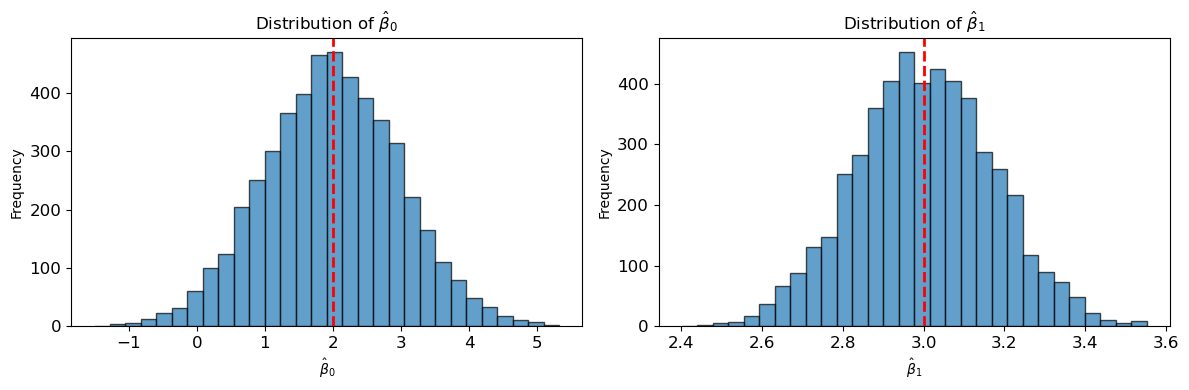

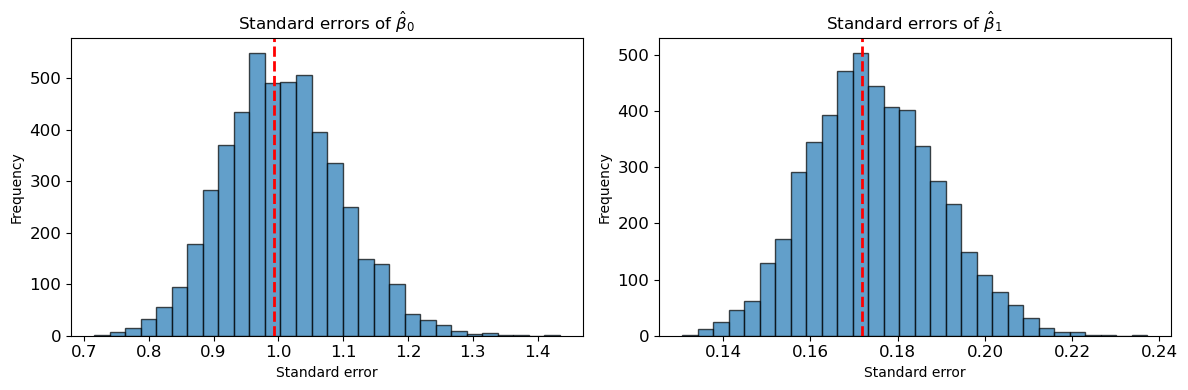

,Parameter,True Value,Mean Estimate,MC Standard Deviation,Average SE
0,beta0,2,1.984161,0.993271,1.006591
1,beta1,3,3.002326,0.171742,0.174530


In [11]:
summary_mc = monte_carlo_OLS(
    n=100, M=5000, beta0=2, beta1=3, sigma_u=5,
    x_dist="uniform", x_params=(0, 10),
    rho_ux=0, heteroskedastic=False,
)

# Part 5: Transformationer

### Lineære transformationer

In [12]:
result_base = OLS_SLR(data['wage'], data['educ'], quiet=True) # Base regression
summary(result_base, 'Base Regression (wage, educ)')

data['wage2010'] = data['wage'] * 1.37 # Timeløn i 2010-DKK priser
result_wage2010 = OLS_SLR(data['wage2010'], data['educ'], quiet=True)
summary(result_wage2010, "Timeløn i 2010-DKK priser -  y=wage* 1.37")

data['educ_month'] = data['educ'] * 12 # Uddannelse i måneder
result_educ_month = OLS_SLR(data['wage'], data['educ_month'], quiet=True)
summary(result_educ_month, "Uddannelse i måneder")

data['educ_9'] = data['educ'] - 9 # Uddannelse relativt til 9. klasse
result_educ_9 = OLS_SLR(data['wage'], data['educ_9'], quiet=True)
summary(result_educ_9,"Uddannelse relativt til 9. klasse")


Base Regression (wage, educ)
Parameter                        Estimate   Std. Error
-------------------------------------------------------
bhat0 (const)                     90.3364       4.9594
bhat1 (educ)                       4.2670       0.4161
R^2: 0.0890

Timeløn i 2010-DKK priser -  y=wage* 1.37
Parameter                        Estimate   Std. Error
-------------------------------------------------------
bhat0 (const)                    123.7609       6.7944
bhat1 (educ)                       5.8458       0.5701
R^2: 0.0890

Uddannelse i måneder
Parameter                        Estimate   Std. Error
-------------------------------------------------------
bhat0 (const)                     90.3364       4.9594
bhat1 (educ_month)                 0.3556       0.0347
R^2: 0.0890

Uddannelse relativt til 9. klasse
Parameter                        Estimate   Std. Error
-------------------------------------------------------
bhat0 (const)                    128.7392       1.7135
bhat1 

In [13]:
# Prøv at se om I kan replikere den originale regression ud fra den transformerede, eksempelvis
print(result_educ_month['beta_1']*12)

4.266979431492384


# Part 6: Data visualization

### Plot data and fitted line

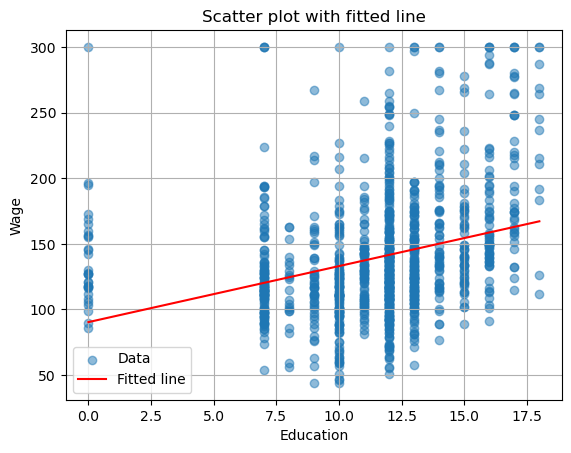

In [14]:
data["y"] = data["wage"]
# data["y"] = np.log(data["wage"])  # Uncomment to transform y.

result = OLS_SLR(data["y"], data["educ"], quiet=True)
data["yhat"] = result["yhat"]
ordered = data.sort_values("educ")

fig, ax = plt.subplots()
ax.scatter(data["educ"], data["y"], alpha=0.5, label="Data")
ax.plot(ordered["educ"], ordered["yhat"], color="red", label="Fitted line")
ax.set(xlabel="Education", ylabel="Wage", title="Scatter plot with fitted line")
ax.legend()
ax.grid(True)
plt.show()

### Binned Scatter plot

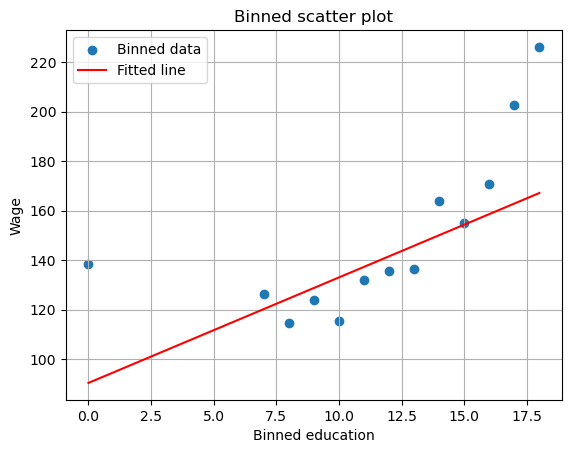

In [15]:
# Include the lowest bin so observations with educ == 0 are not dropped.
bins = np.arange(data["educ"].min(), data["educ"].max() + 1)
data["bin"] = pd.cut(data["educ"], bins=bins, include_lowest=True)
binned_data = (
    data.groupby("bin", observed=True)
    .agg(y=("y", "mean"), yhat=("yhat", "mean"), educ=("educ", "mean"))
    .reset_index()
)

fig, ax = plt.subplots()
ax.scatter(binned_data["educ"], binned_data["y"], label="Binned data")
ax.plot(binned_data["educ"], binned_data["yhat"], color="red", label="Fitted line")
ax.set(xlabel="Binned education", ylabel="Wage", title="Binned scatter plot")
ax.legend()
ax.grid(True)
plt.show()